# Two-Qubit Cell: Meshing Part of the 17-Qubit Chip

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F54-Wallraff_TwoQubit_Cell_Mesh.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F54-Wallraff_TwoQubit_Cell_Mesh.ipynb)

> 💡 **What you need.** Meshing needs gmsh: `pip install "quantum-metal[mesh]"`. The capacitance step at the end also needs [ElmerFEM](https://www.elmerfem.org/) (`ElmerSolver` on your `PATH`); without it the notebook stops after the mesh and says so. The outputs shown here come from a run with gmsh 4.15 and ElmerFEM 26.2.

A full chip is far too big to simulate in one piece, and it does not need to be: the quantities that set a qubit's frequency and its coupling to a neighbor are local. This notebook takes one cell of the [17-qubit surface-code chip](53-Wallraff_17Qubit_SurfaceCode.ipynb) — data qubit `D5`, auxiliary qubit `Z3`, and the coupler between them — builds it as a small design of its own, and meshes it for the open-source finite-element path: gmsh for the mesh, ElmerFEM for the capacitance matrix.

**What you'll learn**

- how to cut a cell out of a larger design as its own, cropped design (rather than filtering the big one, which keeps the full-chip ground plane);
- how to render and mesh it with `QGmshRenderer`, and look at the mesh without a GUI;
- how to hand the same design to `QElmerRenderer` for the capacitance matrix.

The cell uses exactly the geometry of the full chip: `build_cell()` runs the same builder stages on a subset of the qubits.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal with the mesher.
# !pip install -q "quantum-metal[mesh]"

In [2]:
import shutil
import sys
import tempfile
import time
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

import qiskit_metal as qm
from qiskit_metal.validation import DEFAULT_RULES, SHAPE_RULES, validate

warnings.filterwarnings("ignore", category=FutureWarning)

# The builder and measured geometry are shared with the 17-qubit notebook.
RES = Path("resources/wallraff_17q")
if not RES.exists():
    RES.mkdir(parents=True)
    base = ("https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
            "tutorials/Appendix%20C%20Circuit%20examples/F.%20Small-quantum-chips/"
            "resources/wallraff_17q/")
    for f in ("wallraff_17q.py", "geometry.json"):
        urllib.request.urlretrieve(base + f, RES / f)
sys.path.insert(0, str(RES))

import wallraff_17q as chip

try:
    import gmsh
    from qiskit_metal.renderers.renderer_gmsh.gmsh_renderer import QGmshRenderer
    HAVE_GMSH = True
except Exception as error:  # not installed, or a system library is missing
    HAVE_GMSH = False
    print("gmsh unavailable:", error)

## 1. Build the cell

`build_cell()` makes a `MultiPlanar` design — the layer stack the gmsh and Elmer renderers read — with its chip cropped to the two qubits plus a 0.35 mm margin, and places the qubits and their coupler exactly as on the full chip.

cell: 2.3092mm x 0.7mm, components: ['D5', 'Z3', 'CPL_D5_Z3']


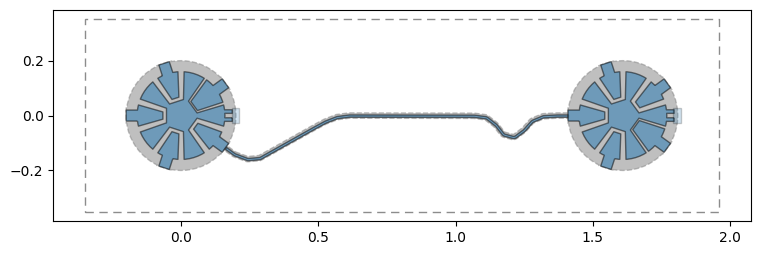

Design rules passed (12 rules ran, no findings).


In [3]:
design = chip.build_cell(("D5", "Z3"))
size = design.chips.main.size
print(f"cell: {size.size_x} x {size.size_y}, components: {list(design.components)}")

fig = qm.view(design)
fig.set_size_inches(9, 3.2)
display(fig)
print(validate(design, rules=[*DEFAULT_RULES, *SHAPE_RULES]).report())

## 2. Mesh it with gmsh

The junctions are skipped: in an electrostatic (capacitance) simulation a Josephson junction is a lumped inductor, added afterwards in the circuit model. The mesh is fine near the metal edges and coarse far away (`min_size`/`max_size`).

In [4]:
if HAVE_GMSH:
    mesher = QGmshRenderer(design)
    if not gmsh.isInitialized():
        gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)  # keep gmsh's progress log out
    mesher.options.mesh.min_size = "5um"
    mesher.options.mesh.max_size = "80um"
    start = time.time()
    mesher.render_design(skip_junctions=True)
    tags, coords, _ = gmsh.model.mesh.getNodes()
    _, triangles = gmsh.model.mesh.getElementsByType(2)
    _, tetrahedra = gmsh.model.mesh.getElementsByType(4)
    print(f"meshed in {time.time() - start:.0f} s: {len(tags):,} nodes, "
          f"{len(triangles) // 3:,} triangles, {len(tetrahedra) // 4:,} tetrahedra")

meshed in 37 s: 109,821 nodes, 140,275 triangles, 609,462 tetrahedra


### Look at the mesh

gmsh has its own viewer (`mesher.launch_gui()`), but it needs a display. The cell below draws the triangles that lie in the plane of the metal instead: they crowd along every metal edge, where the field changes fastest.

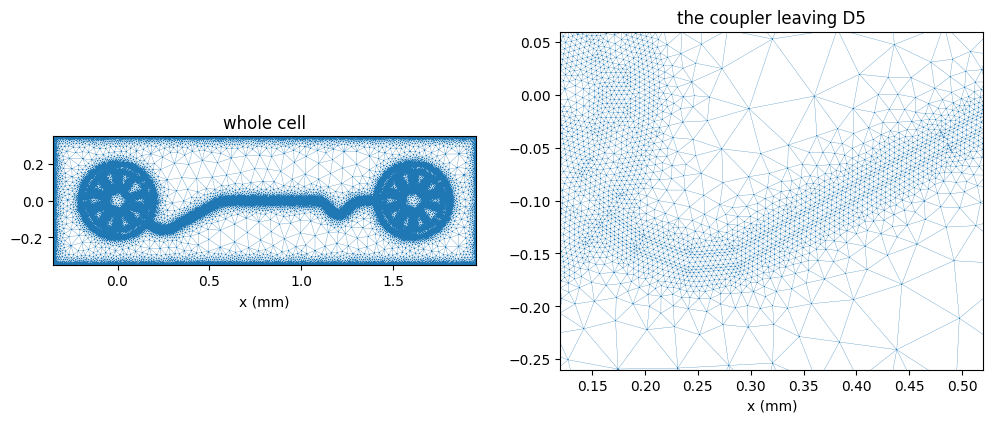

In [5]:
if HAVE_GMSH:
    xyz = coords.reshape(-1, 3)
    index = {tag: i for i, tag in enumerate(tags)}
    tri = np.vectorize(index.get)(triangles.reshape(-1, 3))
    in_plane = np.ptp(xyz[tri, 2], axis=1) < 1e-9
    plane = tri[in_plane & np.isclose(xyz[tri[:, 0], 2], 0.0)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, (x0, x1, y0, y1), title in (
        (axes[0], (-0.35, 1.95, -0.35, 0.35), "whole cell"),
        (axes[1], (0.12, 0.52, -0.26, 0.06), "the coupler leaving D5"),
    ):
        ax.triplot(xyz[:, 0], xyz[:, 1], plane, lw=0.2, color="tab:blue")
        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_xlabel("x (mm)")
    plt.show()

In [6]:
if HAVE_GMSH:
    mesh_file = Path(tempfile.gettempdir()) / "wallraff_D5_Z3.msh"
    mesher.export_mesh(str(mesh_file))
    print(f"{mesh_file.name}: {mesh_file.stat().st_size / 1e6:.1f} MB")
    mesher.close()

wallraff_D5_Z3.msh: 30.1 MB


## 3. Capacitance matrix with ElmerFEM (optional)

`QElmerRenderer` meshes the same design through gmsh and solves the electrostatics in Elmer. Every separate piece of metal — each qubit island, each pad, the coupler — becomes a row of the capacitance matrix. That matrix is the input to the lumped-oscillator model (LOM) that gives each qubit's charging energy and the coupling between D5 and Z3; tutorial 4.19 walks through that step.

In [7]:
if not HAVE_GMSH or shutil.which("ElmerSolver") is None:
    print("ElmerSolver not found: install ElmerFEM (https://www.elmerfem.org/) "
          "to compute the capacitance matrix of this cell.")
else:
    from qiskit_metal.renderers.renderer_elmer.elmer_renderer import QElmerRenderer

    elmer = QElmerRenderer(design)
    if not gmsh.isInitialized():
        gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    # Elmer's input, mesh and results go to a scratch folder.
    elmer.options.simulation_dir = tempfile.mkdtemp(prefix="wallraff_cell_")
    elmer.gmsh.options.mesh.min_size = "5um"
    elmer.gmsh.options.mesh.max_size = "80um"
    start = time.time()
    elmer.render_design(skip_junctions=True)
    elmer.add_solution_setup("capacitance")
    elmer.run("capacitance")
    print(f"solved in {time.time() - start:.0f} s; capacitance matrix in fF:")
    cmat = elmer.capacitance_matrix
    display(cmat.round(2))
    elmer.close()

11:56PM 33s INFO [run]: Mesh not exported yet; exporting it now.


11:56PM 33s INFO [run]: Running ElmerGrid on input mesh from Gmsh...


11:56PM 35s INFO [run]: Running ElmerSolver for solver type: 'capacitance'


solved in 52 s; capacitance matrix in fF:


,Z3_contact_cpl3,D5_circle_inner,Z3_circle_inner,ground_plane
Z3_contact_cpl3,418.39,-18.39,-18.40,-381.59
D5_circle_inner,-18.39,167.02,-0.06,-148.56
Z3_circle_inner,-18.40,-0.06,168.07,-149.61
ground_plane,-381.59,-148.56,-149.61,300.00


### Reading the matrix

Each row is one piece of metal that is not connected to another: the two qubit islands, the coupler, and ground. The coupler and the two pads it joins form one conductor; the renderer names it after one of its pieces (`Z3_contact_cpl3`). The pads that have no line attached reach the pocket edge in this model, so they are part of ground. Ground is the reference conductor, and the renderer fills its diagonal entry with a placeholder (300 fF); every other entry is computed.

The diagonal entry of an island is its total capacitance $C_\Sigma$, which sets the charging energy $E_C = e^2/2C_\Sigma$; the off-diagonal entry between an island and the coupler is what couples the two qubits through it. These numbers describe this cut-out cell: on the full chip the other pads connect to readout resonators and to other couplers rather than to ground, and the junction adds its own capacitance, so they are not a prediction of the measured device.

In [8]:
if "cmat" in globals():
    from scipy.constants import e, h

    coupler = next(n for n in cmat.index if "cpl" in n)  # the coupler's net
    for q in ("D5", "Z3"):
        island = f"{q}_circle_inner"
        c_sigma = cmat.loc[island, island]
        e_c = e**2 / (2 * h * c_sigma * 1e-15) / 1e6
        print(f"{q}: C_sigma = {c_sigma:5.1f} fF   E_C/h = {e_c:4.0f} MHz   "
              f"C to coupler = {-cmat.loc[island, coupler]:4.1f} fF")

D5: C_sigma = 167.0 fF   E_C/h =  116 MHz   C to coupler = 18.4 fF
Z3: C_sigma = 168.1 fF   E_C/h =  115 MHz   C to coupler = 18.4 fF


## Where to go next

- **LOM analysis:** turn the capacitance matrix into qubit frequencies and the D5–Z3 coupling — tutorial [4.19 Analyze a transmon using ElmerFEM](../../tut/4-Analysis/4.19-Analyze-a-transmon-using-ElmerFEM.ipynb), section 4.
- **A different pair:** `chip.build_cell(("X3", "D8"))` builds any two neighbors, or more: pass a longer tuple.
- **Mesh density:** halve `min_size` and see how the matrix moves — a quick convergence check.

## References

1. S. Krinner, N. Lacroix, A. Remm *et al.*, "Realizing repeated quantum error correction in a distance-three surface code," *Nature* **605**, 669–674 (2022). [doi:10.1038/s41586-022-04566-8](https://doi.org/10.1038/s41586-022-04566-8)
2. C. Geuzaine, J.-F. Remacle, "Gmsh: A 3-D finite element mesh generator with built-in pre- and post-processing facilities," *Int. J. Numer. Methods Eng.* **79**, 1309–1331 (2009). [doi:10.1002/nme.2579](https://doi.org/10.1002/nme.2579)
3. ElmerFEM, open-source multiphysics finite-element software, CSC – IT Center for Science: [elmerfem.org](https://www.elmerfem.org/)